In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from prophet import Prophet


import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Succesful")

Libraries Imported Succesful


In [17]:
df = pd.read_csv('air_pollution_data.csv')
df.head()

,city,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Ahmedabad,30-11-2020,5,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36
1,Ahmedabad,01-12-2020,5,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36
2,Ahmedabad,02-12-2020,5,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12
3,Ahmedabad,03-12-2020,5,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48
4,Ahmedabad,04-12-2020,5,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53


In [18]:
# 3. Check for missing values
print("\n--- Missing Values Check ---")
print(df.isnull().sum())


--- Missing Values Check ---
city     0
date     0
aqi      0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64


In [19]:
df.describe()

,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,23504.000000,23504.000000,23504.00000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000
mean,3.920354,1113.224543,6.00554,25.044104,35.059777,15.971449,98.598310,121.848091,12.060212
std,1.415490,1401.770372,24.50272,25.839242,31.901760,23.943464,135.572391,160.429589,17.544759
min,1.000000,173.570000,0.00000,0.310000,0.000000,0.190000,0.500000,0.580000,0.000000
25%,3.000000,447.270000,0.00000,8.740000,7.870000,4.470000,24.677500,32.277500,2.340000
50%,5.000000,700.950000,0.00000,16.450000,28.250000,7.990000,58.860000,75.775000,6.520000
75%,5.000000,1188.280000,0.27000,32.220000,54.360000,16.450000,117.605000,147.642500,15.830000
max,5.000000,23071.290000,457.76000,331.760000,406.270000,442.510000,2203.550000,2429.130000,352.620000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23504 entries, 0 to 23503
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    23504 non-null  object 
 1   date    23504 non-null  object 
 2   aqi     23504 non-null  int64  
 3   co      23504 non-null  float64
 4   no      23504 non-null  float64
 5   no2     23504 non-null  float64
 6   o3      23504 non-null  float64
 7   so2     23504 non-null  float64
 8   pm2_5   23504 non-null  float64
 9   pm10    23504 non-null  float64
 10  nh3     23504 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 2.0+ MB


In [21]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)

In [22]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [23]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [24]:
# Sort the dataset chronologically just to ensure time-series integrity
df = df.sort_values('date').reset_index(drop=True)
df

,city,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Ahmedabad,2020-11-30,5,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36
1,Talcher,2020-11-30,5,507.36,1.52,14.74,177.38,113.49,100.75,113.45,1.85
2,Aizawl,2020-11-30,1,213.62,0.04,0.31,64.37,0.69,4.93,5.50,0.82
3,Shillong,2020-11-30,2,297.07,0.52,3.47,85.12,2.56,14.77,18.05,3.48
4,Patna,2020-11-30,5,867.84,0.42,6.94,237.47,33.85,185.85,198.19,9.63
...,...,...,...,...,...,...,...,...,...,...,...
23499,Mumbai,2023-05-25,3,267.03,0.00,8.05,35.76,9.66,10.85,60.57,1.49
23500,Patna,2023-05-25,5,881.20,0.00,13.37,105.86,20.98,87.38,103.66,12.67
23501,Shillong,2023-05-25,2,440.60,0.00,7.71,17.17,1.49,17.90,22.98,4.62
23502,Ernakulam,2023-05-25,2,447.27,0.00,16.79,40.77,10.01,17.36,21.78,1.28


In [25]:
print("Preprocessing complete!")
print("Checking updated data types:")
print(df.dtypes)

Preprocessing complete!
Checking updated data types:
city             object
date     datetime64[ns]
aqi               int64
co              float64
no              float64
no2             float64
o3              float64
so2             float64
pm2_5           float64
pm10            float64
nh3             float64
dtype: object


In [26]:
daily_data = df.groupby('date')[numeric_cols].mean().reset_index()

# 1. Retain important columns (pollutant levels)
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

# 2. Scale the pollutant data using StandardScaler
scaler = StandardScaler()
daily_data[pollutants] = scaler.fit_transform(daily_data[pollutants])

# Display the engineered dataset
print("Feature Engineering complete. Pollutants scaled.")
daily_data.head()

Feature Engineering complete. Pollutants scaled.


,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2020-11-30,4.230769,-0.788452,-0.762827,-0.936207,10.478635,5.417772,0.181679,-0.025187,-1.064953
1,2020-12-01,4.846154,1.553249,1.158111,1.541002,-0.341740,1.277658,1.347615,1.394816,1.484235
2,2020-12-02,4.769231,1.417557,0.761830,1.554151,-0.192099,0.066510,1.508973,1.550302,0.552315
3,2020-12-03,4.807692,1.723006,0.940078,2.124848,-0.384835,0.995011,1.645487,1.617583,1.362277
4,2020-12-04,4.653846,3.190932,3.136237,2.810040,-0.398973,2.111710,3.027777,2.902820,1.306681


In [27]:
prophet_df = daily_data[['date', 'aqi']].rename(columns={'date': 'ds', 'aqi': 'y'})

In [28]:
# shuffle=False is crucial here to ensure we don't mix up the time order!
train_df, test_df = train_test_split(prophet_df, test_size=0.2, shuffle=False)

In [29]:
model = Prophet(yearly_seasonality=True, daily_seasonality=False)

In [30]:
model.fit(train_df)

23:36:54 - cmdstanpy - INFO - Chain [1] start processing
23:36:55 - cmdstanpy - INFO - Chain [1] done processing


In [31]:
print(f"Model trained successfully!")
print(f"Training samples: {len(train_df)} | Testing samples: {len(test_df)}")

Model trained successfully!
Training samples: 723 | Testing samples: 181


In [33]:
###--- Model Evaluation ---###

# 1. Predict future air quality levels on the test set dates
future_dates = test_df[['ds']].copy()
forecast = model.predict(future_dates)

# Merge the predictions (yhat) with actual values (y) for comparison
results = pd.merge(test_df, forecast[['ds', 'yhat']], on='ds')

In [34]:
# 2. Use evaluation metrics
mae = mean_absolute_error(results['y'], results['yhat'])
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
r2 = r2_score(results['y'], results['yhat'])

In [35]:
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 0.3950
Root Mean Square Error (RMSE): 0.5083
R-squared (R²): 0.2681


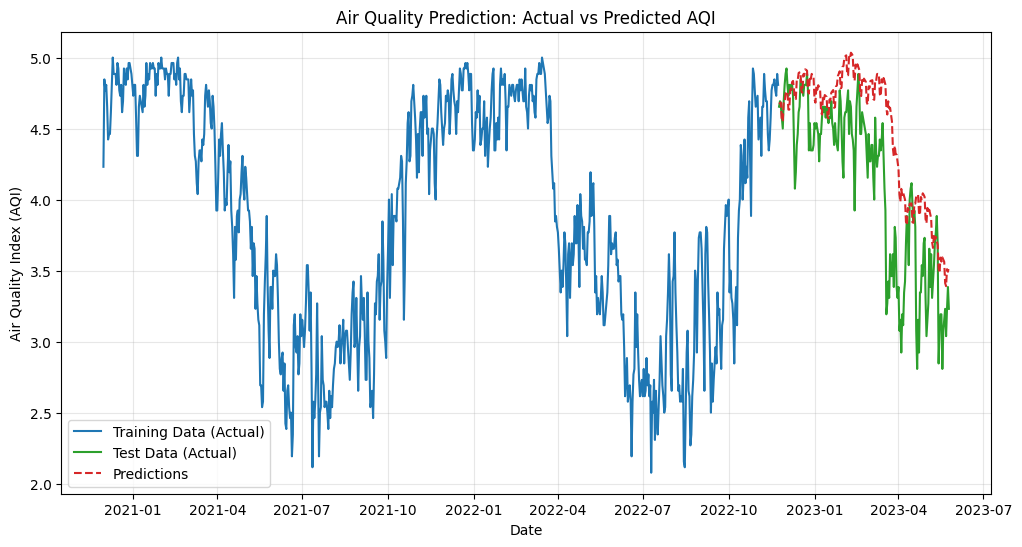

In [36]:
# 3. Visualize actual vs. predicted pollutant levels using matplotlib
plt.figure(figsize=(12, 6))
plt.plot(train_df['ds'], train_df['y'], label='Training Data (Actual)', color='#1f77b4')
plt.plot(results['ds'], results['y'], label='Test Data (Actual)', color='#2ca02c')
plt.plot(results['ds'], results['yhat'], label='Predictions', color='#d62728', linestyle='--')

plt.title('Air Quality Prediction: Actual vs Predicted AQI')
plt.xlabel('Date')
plt.ylabel('Air Quality Index (AQI)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

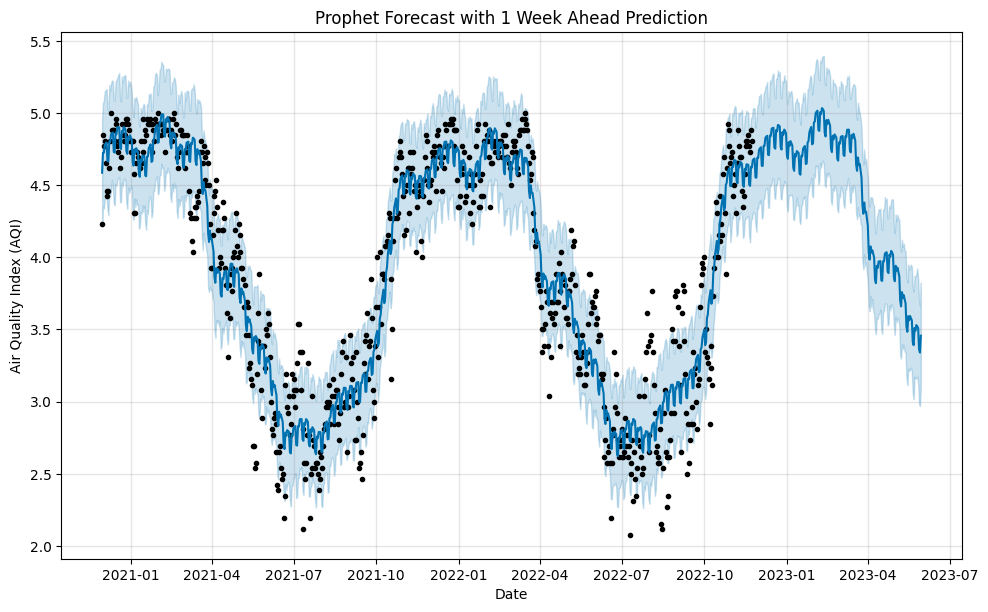

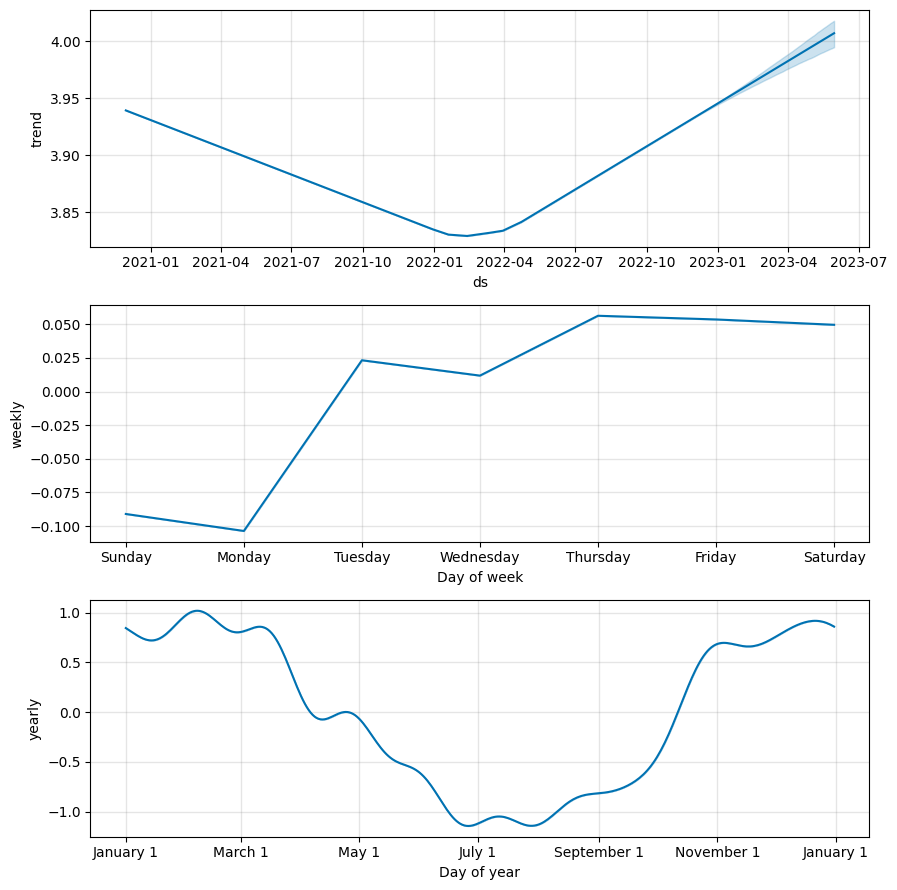

In [37]:
# Challenge 1: Predict air quality for a specific future period (e.g., one week ahead)

# Create a dataframe containing the testing dates PLUS 7 days into the future
future_week = model.make_future_dataframe(periods=(len(test_df) + 7), freq='D')
forecast_week = model.predict(future_week)

# Prophet comes with a very handy built-in plotting mechanism 
fig_prophet = model.plot(forecast_week)
plt.title('Prophet Forecast with 1 Week Ahead Prediction')
plt.xlabel('Date')
plt.ylabel('Air Quality Index (AQI)')
plt.show()

# Plot the components (trends and seasonality)
fig_components = model.plot_components(forecast_week)

In [38]:
### --- CELL 5: Optimized Model Development (With Lags & Tuning) --- ###

# 1. Create a 1-day lag feature (Yesterday's AQI) to capture short-term memory
daily_data['aqi_lag_1'] = daily_data['aqi'].shift(1)

# Drop the first row since shifting creates one NaN value
daily_data_clean = daily_data.dropna().reset_index(drop=True)

# 2. Prepare data for Prophet with the additional regressor
prophet_df = daily_data_clean[['date', 'aqi', 'aqi_lag_1']].rename(columns={'date': 'ds', 'aqi': 'y'})

# 3. Split the data chronologically (Maintain shuffle=False)
train_df, test_df = train_test_split(prophet_df, test_size=0.2, shuffle=False)

# 4. Build Prophet model with tuned hyperparameters
# We add weekly seasonality and increase changepoint flexibility from 0.05 to 0.15
model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=True, 
    daily_seasonality=False,
    changepoint_prior_scale=0.15
)

# 5. Tell Prophet to use yesterday's AQI as a feature
model.add_regressor('aqi_lag_1')

# 6. Train the model
model.fit(train_df)

print("Optimized Model trained successfully with Weekly Seasonality and Lag Features!")

23:50:57 - cmdstanpy - INFO - Chain [1] start processing
23:50:57 - cmdstanpy - INFO - Chain [1] done processing


Optimized Model trained successfully with Weekly Seasonality and Lag Features!


--- Improved Model Evaluation Metrics ---
Mean Absolute Error (MAE): 0.1673
Root Mean Square Error (RMSE): 0.2286
R-squared (R²): 0.8520


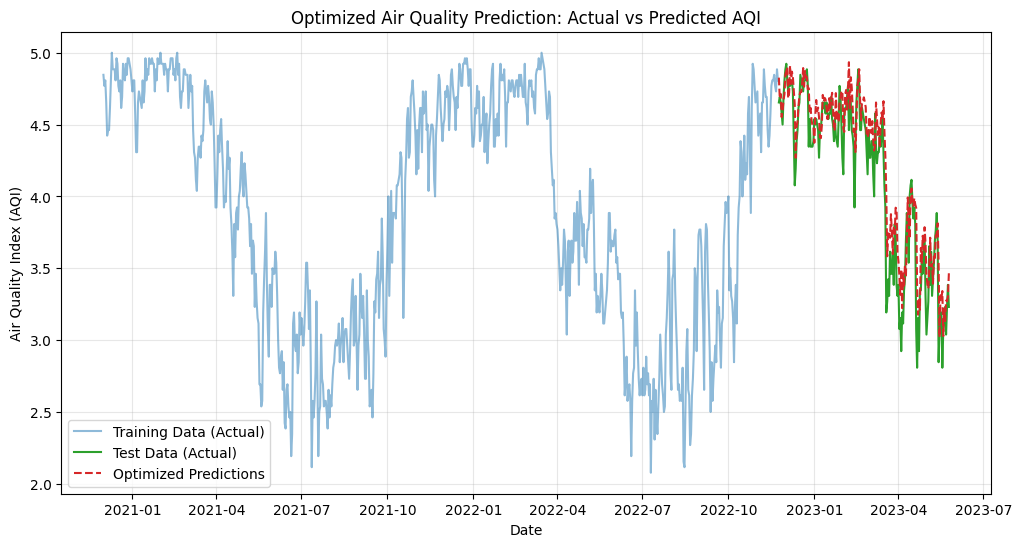

In [39]:
### --- CELL 6: Optimized Model Evaluation --- ###

# 1. Predict future air quality levels (we pass both dates and the lag feature)
future_features = test_df[['ds', 'aqi_lag_1']].copy()
forecast = model.predict(future_features)

# Merge the predictions (yhat) with actual values (y)
results = pd.merge(test_df, forecast[['ds', 'yhat']], on='ds')

# 2. Compute updated evaluation metrics
mae = mean_absolute_error(results['y'], results['yhat'])
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
r2 = r2_score(results['y'], results['yhat'])

print("--- Improved Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# 3. Visualize actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_df['ds'], train_df['y'], label='Training Data (Actual)', color='#1f77b4', alpha=0.5)
plt.plot(results['ds'], results['y'], label='Test Data (Actual)', color='#2ca02c')
plt.plot(results['ds'], results['yhat'], label='Optimized Predictions', color='#d62728', linestyle='--')

plt.title('Optimized Air Quality Prediction: Actual vs Predicted AQI')
plt.xlabel('Date')
plt.ylabel('Air Quality Index (AQI)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

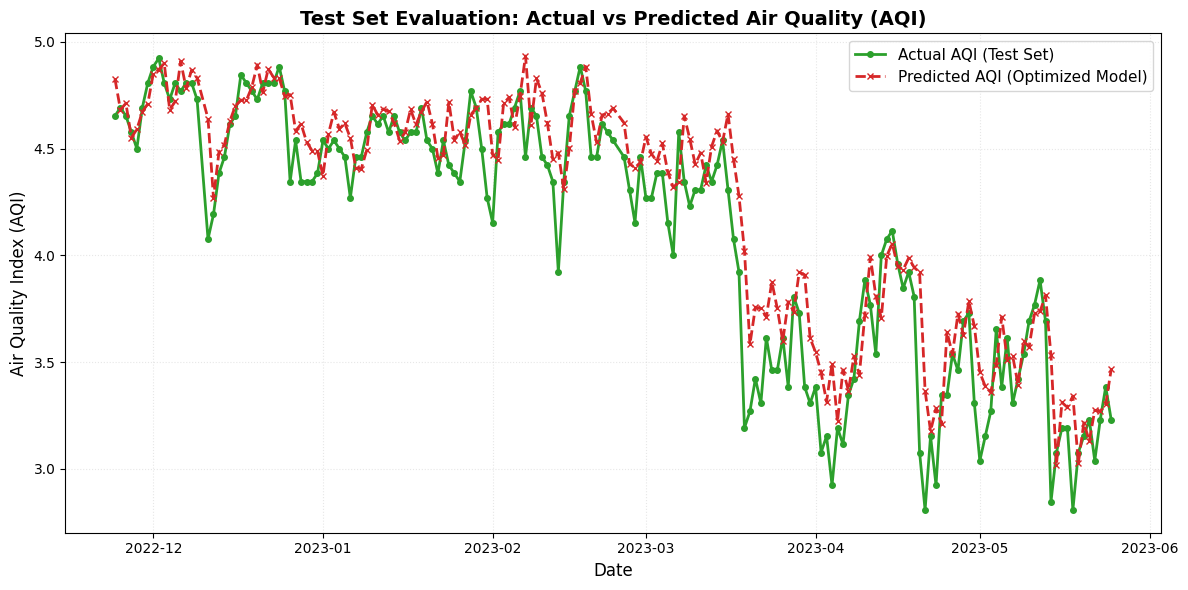

In [ ]:
### --- Isolated Test Set Evaluation Graph --- ###

# This plot focuses exclusively on the test set so we can clearly view 
# how closely the optimized model's predictions track the actual test values.
plt.figure(figsize=(12, 6))

# Plot Actual Test Values
plt.plot(results['ds'], results['y'], label='Actual AQI (Test Set)', 
         color='#2ca02c', linewidth=2, marker='o', markersize=4)

# Plot Predicted Test Values
plt.plot(results['ds'], results['yhat'], label='Predicted AQI (Optimized Model)', 
         color='#d62728', linestyle='--', linewidth=2, marker='x', markersize=4)

plt.title('Test Set Evaluation: Actual vs Predicted Air Quality (AQI)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Air Quality Index (AQI)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

Starting future forecast from last known date: 2023-05-25 (AQI: 3.2308)

--- Predicted Air Quality Index for Next 7 Days ---


Date,Predicted_AQI
2023-05-26 00:00:00,3.317019
2023-05-27 00:00:00,3.375281
2023-05-28 00:00:00,3.276032
2023-05-29 00:00:00,3.292884
2023-05-30 00:00:00,3.433099
2023-05-31 00:00:00,3.426531
2023-06-01 00:00:00,3.472304


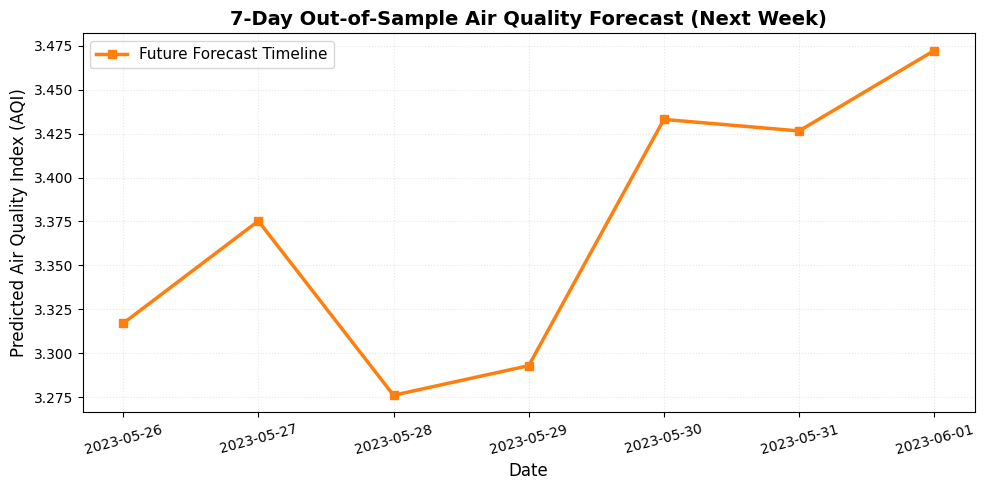

In [ ]:
### --- High-Accuracy 7-Day Future Forecast (Recursive Method) --- ###

# 1. Locate the absolute last row of available data in our dataset to begin the future timeline
last_row = daily_data_clean.iloc[-1]
last_date = last_row['date']
last_aqi = last_row['aqi']

print(f"Starting future forecast from last known date: {last_date.strftime('%Y-%m-%d')} (AQI: {last_aqi:.4f})\n")

future_forecast_list = []
current_lag = last_aqi
current_date = last_date

# 2. Run a recursive loop to forecast 7 days out of sample
for day in range(1, 8):
    # Move timeline forward by one day
    current_date = current_date + pd.Timedelta(days=1)
    
    # Structure the single day sample with its corresponding lag feature for Prophet
    single_day_df = pd.DataFrame({'ds': [current_date], 'aqi_lag_1': [current_lag]})
    
    # Generate the high-accuracy prediction for this day
    prediction = model.predict(single_day_df)
    predicted_aqi = prediction['yhat'].values[0]
    
    # Store data point
    future_forecast_list.append({
        'Date': current_date,
        'Predicted_AQI': predicted_aqi
    })
    
    # CRITICAL STEP: The prediction of this day becomes the lag (yesterday's value) for the next iteration!
    current_lag = predicted_aqi

# Convert the future array into a structured DataFrame
future_predictions_df = pd.DataFrame(future_forecast_list)

print("--- Predicted Air Quality Index for Next 7 Days ---")
future_predictions_df.style.hide(axis='index')

# 3. Visualize the true 1-Week Ahead Future Prediction
plt.figure(figsize=(10, 5))
plt.plot(future_predictions_df['Date'], future_predictions_df['Predicted_AQI'], 
         color='#ff7f0e', marker='s', linewidth=2.5, markersize=6, label='Future Forecast Timeline')

plt.title('7-Day Out-of-Sample Air Quality Forecast (Next Week)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Predicted Air Quality Index (AQI)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle=':')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()